# Dune

**Оглавление**<a id='toc0_'></a>       
- [1. Предварительная обработка данных](#toc1_)    
  - [1.1. Чтение и загрузка данных](#toc1_1_)    
  - [1.2. Первичный анализ данных](#toc1_2_)    
  - [1.3. Разделение выборки на обучающую и тестовую выборки](#toc1_3_)    
  - [1.4. Обработка вещественных признаков (заполнение пропусков)](#toc1_4_)    
  - [1.5. Кодирование категориальных признаков](#toc1_5_)    
  - [1.6. Детекция выбросов и аномалий в данных](#toc1_6_)    
  - [1.7. Подведение итогов раздела 1](#toc1_7_)    
- [2. Генерация новых признаков](#toc2_)    
  - [2.1. Корреляционный анализ входных признаков (построение тепловых карт корреляции)](#toc2_1_)    
  - [2.2. Исправление проблемы мультиколлинеарности в данных](#toc2_2_)    
  - [2.3. Скалирование данных](#toc2_3_)    
  - [2.4. Подведение итогов раздела 2](#toc2_4_)    
- [3. Выбор моделей ML и метрик](#toc3_)    
- [4. Обучение моделей ML и подбор гиперпараметров](#toc4_)    
- [5. Вычисление метрик на новых данных](#toc5_)    
- [6. Результат работы](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

`Задача`
<!-- В этой ячейке необходимо указать, какую задачу вы решаете, в развернутом виде -->
Необходимо по данным о координатах места наблюдения, времени года, погодных условиях, температуре, относительной влажности, скорости ветра, количестве осадков и специальных показателях, характеризующих состояние атмосферы и поверхности пустыни, определить, будет ли песчаная буря. Если случится, то какую территорию она затронет.

Целевая переменная $\text{area} \in [0; +\infty)$ непрерывна, поэтому исходная задача формулируется как **задача регрессии**. Ввиду сильной правосторонней асимметрии и наличия экстремальных выбросов к целевой переменной применяется логарифмическое преобразование $y' = \ln(\text{area} + 1)$. Таким образом, обучение моделей регрессии будет производиться на трансформированной шкале $y'$ с последующим возвратом предсказаний к исходным единицам через обратное преобразование $\hat{y} = \exp(\hat{y}') - 1$.

`Описание исходных данных`

### <a id='toc0_0_1_'></a>[1. Семантика и ожидаемые типы данных](#toc0_)

| Признак | Семантика (описание признака) | Ожидаемый тип данных | Единицы измерения / Формат | Возможные значения |
| :--- | :--- | :--- | :--- | :--- |
| **X** | Пространственная координата $X$ на координатной сетке сектора | Дискретный / Целочисленный (`int`) | Координата сетки | $1 \dots 9$ |
| **Y** | Пространственная координата $Y$ на координатной сетке сектора | Дискретный / Целочисленный (`int`) | Координата сетки | $1 \dots 9$ |
| **month** | Месяц наблюдения / замера | Категориальный / Порядковый (`string` / `category`) | Месяц года | `'jan'` $\dots$ `'dec'` |
| **day** | День недели замера | Категориальный / Порядковый (`string` / `category`) | День недели | `'mon'` $\dots$ `'sun'` |
| **spice concentration index** | Индекс концентрации спайса (меланжа) в атмосфере / приповерхностном слое | Непрерывный вещественный (`float`) | Условный индекс | Вещественные $> 0$ |
| **oil concentration index** | Индекс концентрации масляных / нефтяных паров | Непрерывный вещественный (`float`) | Условный индекс | Вещественные $> 0$ |
| **fossil concentration index** | Индекс концентрации ископаемых / минеральных взвесей | Непрерывный вещественный (`float`) | Условный индекс | Вещественные $> 0$ |
| **carbon concentration index** | Индекс концентрации углерода / углеродной пыли | Непрерывный вещественный (`float`) | Условный индекс | Вещественные $> 0$ |
| **temp** | Температура воздуха окружающей среды | Непрерывный вещественный (`float`) | Градусы Цельсия ($^\circ\text{C}$) | Вещественные значения |
| **relative humidity** | Относительная влажность воздуха | Непрерывный вещественный (`float`) | Проценты ($\%$) | $[0, 100]$ |
| **wind speed** | Скорость ветра (песчаного потока) | Непрерывный вещественный (`float`) | км/ч (или м/с) | Вещественные $\ge 0$ |
| **rain** | Количество осадков (дождя / влаги) за единицу времени | Непрерывный вещественный (`float`) | мм / $\text{м}^2$ | Вещественные $\ge 0$  |
| **area** | **Целевой признак**: площадь пораженной / активной песчаной зоны (бури / возгорания) | Непрерывный вещественный (`float`) | гектары ($\text{га}$) | Вещественные $\ge 0$ |

### <a id='toc0_0_2_'></a>[2. Формулы прикладной области](#toc0_)

#### <a id='toc0_0_2_1_'></a>[Разрешенные к использованию формулы (Feature Engineering и трансформация признаков):](#toc0_)
1. **Логарифмирование целевой переменной:**
   Так как площадь (`area`) имеет тяжелый правый хвост и преобладание нулевых значений (сильная асимметрия распределения), для обучения регрессионных моделей рекомендуется логарифмическое преобразование:
   $$y' = \ln(\text{area} + 1)$$
2. **Циклическое (тригонометрическое) кодирование времени:**
   Для сохранения циклической природы месяцев и дней недели:
   $$\sin\left(\frac{2\pi \cdot t}{T}\right), \quad \cos\left(\frac{2\pi \cdot t}{T}\right)$$
   где $T = 12$ для месяцев и $T = 7$ для дней недели.
3. **Расчет евклидова расстояния до базовых точек:**
   $$d = \sqrt{(X - X_0)^2 + (Y - Y_0)^2}$$

#### <a id='toc0_0_2_2_'></a>[Запрещенные формулы (Data Leakage):](#toc0_)
* Использование формул обратного пересчета площади `area` напрямую из комбинации индексов концентрации или погодных факторов для искусственного восстановления целевой переменной.
* Вычисление глобальных статистик (среднее $\mu$, дисперсия $\sigma^2$, min/max) по всей выборке до разбиения на обучающую (Train) и тестовую (Test) части.

`Фиксации виртуального окружения`
<!-- 
    В этой и последующих ячейках предлагается зафиксировать информацию о виртуальном окружении, а именно:
    1. версию питона
    2. версию и список используемых библиотек
    3. основные и часто встречающиеся импорты (pandas, numpy, typing, warnings и т.д.)
    4. случайный сид (seed / random_state)
-->

### <a id='toc0_0_3_'></a>[Спецификация среды выполнения](#toc0_)
* **Python:** `>= 3.9` 
* **Базовые зависимости для анализа данных и визуализации:**
  * `numpy==2.0.2`
  * `pandas==2.3.3`
  * `matplotlib==3.9.4`
  * `seaborn==0.13.2`
  * `scikit-learn-1.6.1`
  
* **Среда разработки и ядро:**
  * `notebook==7.5.7`

### <a id='toc0_0_4_'></a>[Воспроизводимость](#toc0_)
Для обеспечения полной детерминированности расчетов, разбиений данных и обучения моделей зафиксирован глобальный сид:
$$\text{RANDOM\_STATE} = 81$$

# <a id='toc1_'></a>[1. Предварительная обработка данных](#toc0_)

## <a id='toc1_1_'></a>[1.1. Чтение и загрузка данных](#toc0_)

Поскольку в предложенном датасете данные разделены с помощью ";", то при чтении используется `sep=';'`. Датасет находится в папка `data`.

In [1]:
import pandas as pd

data = pd.read_csv('../data/dune.csv', sep=';')
data.head(5)

,X,Y,month,day,spice concentration index,oil concentration index,fossil concentration index,carbon concentration index,temp,relative humidity,wind speed,rain,area
0,7,5,mar,fri,NaN,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,NaN,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## <a id='toc1_2_'></a>[1.2. Первичный анализ данных](#toc0_)

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   X                           517 non-null    int64  
 1   Y                           517 non-null    int64  
 2   month                       517 non-null    object 
 3   day                         517 non-null    object 
 4   spice concentration index   465 non-null    float64
 5   oil concentration index     517 non-null    float64
 6   fossil concentration index  481 non-null    float64
 7   carbon concentration index  517 non-null    float64
 8   temp                        517 non-null    float64
 9   relative humidity           517 non-null    int64  
 10  wind speed                  450 non-null    float64
 11  rain                        388 non-null    float64
 12  area                        517 non-null    float64
dtypes: float64(8), int64(3), object(2)


In [3]:
data.describe()

,X,Y,spice concentration index,oil concentration index,fossil concentration index,carbon concentration index,temp,relative humidity,wind speed,rain,area
count,517.000000,517.000000,465.000000,517.000000,481.000000,517.000000,517.000000,517.000000,450.000000,388.000000,517.000000
mean,4.669246,4.299807,90.637419,110.872340,550.594595,9.021663,18.889168,44.288201,4.028889,0.024742,12.847292
std,2.313778,1.229900,5.594469,64.046482,245.433115,4.559477,5.806625,16.317469,1.819900,0.334117,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.300000,68.600000,442.900000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.800000,142.400000,713.900000,10.800000,22.800000,53.000000,5.400000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


Целевая переменная (`area`) имеет правостороннюю асимметрию: среднее равно 12.85, а медиана — всего 0.52, при этом 25%-квантиль равен 0. Это подтверждает гипотезу о логарифмировании с цельую приблизить распределение к нормальному.

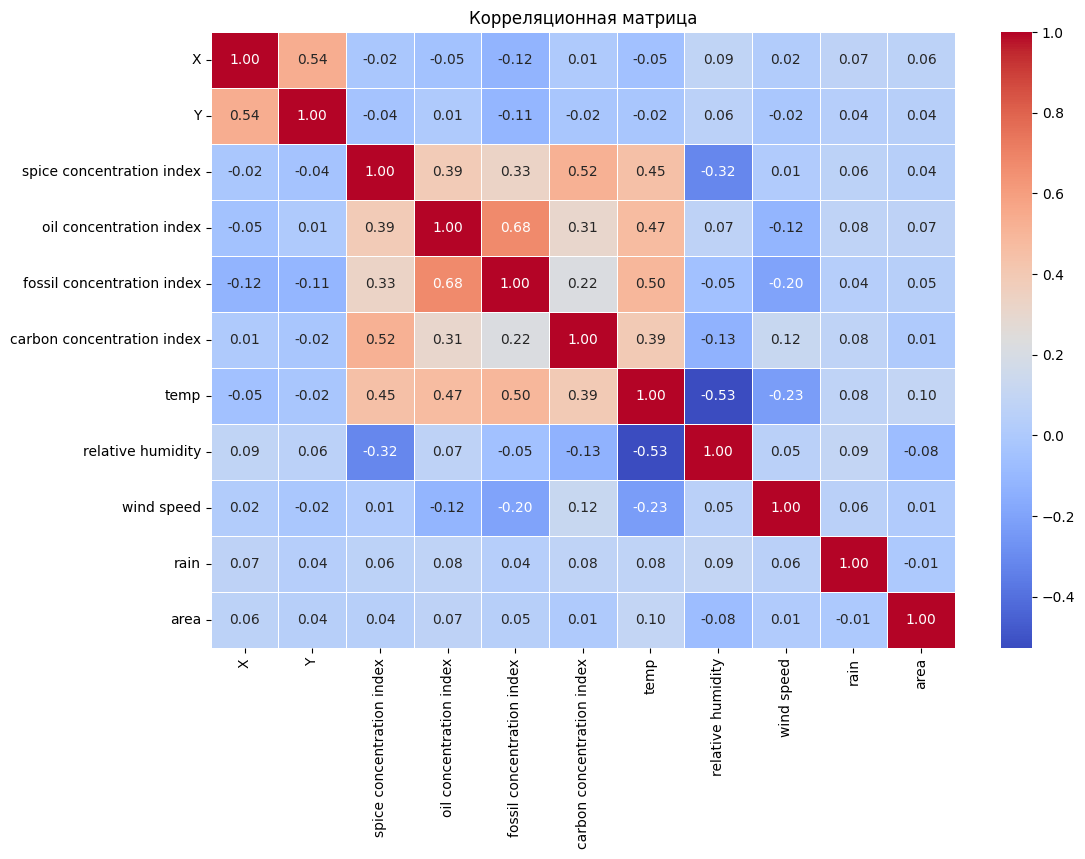

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

col_for_heatmap = ['X', 'Y', 'spice concentration index', 'oil concentration index', 'fossil concentration index', 'carbon concentration index', 'temp', 'relative humidity', 'wind speed', 'rain', 'area']
sns.heatmap(data[col_for_heatmap].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

Максимальный коэффициент корреляции в выборке составляет $0.68$ (между `oil` и `fossil`), что соответствует умеренной линейной связи. Пороговым значением для удаления дублирующих факторов традиционно считается $\vert{}r\vert{} \ge 0.85\dots0.90$.

In [5]:
print(data.duplicated().sum())

duplicates = data[data.duplicated(keep=False)]
duplicates

1


,X,Y,month,day,spice concentration index,oil concentration index,fossil concentration index,carbon concentration index,temp,relative humidity,wind speed,rain,area
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66


In [6]:
data = data.drop_duplicates()

print(data.duplicated().sum())

0


Дубликаты обнаружены и удалены.

## <a id='toc1_3_'></a>[1.3. Разделение выборки на обучающую и тестовую выборки](#toc0_)

При помощи метода `train_test_split` сформируем обучающую и тестовую выборки. Поскольку в исходном датасете около 517 записей, на тест оставим 15% данных.

In [7]:
from sklearn.model_selection import train_test_split

y = ['area']

train_df, test_df = train_test_split(data, shuffle=True, random_state=81, test_size=0.15)

x_train, x_test = train_df.drop(columns=y), test_df.drop(columns=y)
y_train, y_test = train_df[y], test_df[y]

## <a id='toc1_4_'></a>[1.4. Обработка вещественных признаков (заполнение пропусков)](#toc0_)

In [8]:
x_train.describe()

,X,Y,spice concentration index,oil concentration index,fossil concentration index,carbon concentration index,temp,relative humidity,wind speed,rain
count,438.000000,438.000000,394.000000,438.000000,404.000000,438.000000,438.000000,438.000000,387.000000,329.000000
mean,4.648402,4.296804,90.445178,110.484018,548.325248,9.006164,18.892009,44.470320,4.066150,0.009726
std,2.277064,1.248721,5.941375,64.826103,245.141343,4.651919,5.836013,16.687401,1.863438,0.086407
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000
25%,3.000000,4.000000,90.225000,57.675000,440.100000,6.500000,15.525000,33.000000,2.700000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,659.750000,8.400000,19.300000,41.000000,4.000000,0.000000
75%,6.000000,5.000000,92.600000,142.400000,713.225000,10.700000,22.800000,53.750000,5.400000,0.000000
max,9.000000,9.000000,96.100000,290.000000,855.300000,56.100000,33.300000,100.000000,9.400000,1.000000


In [9]:
(x_train.isna().sum() / x_train.shape[0] * 100).sort_values(ascending=False)

rain                          24.885845
wind speed                    11.643836
spice concentration index     10.045662
fossil concentration index     7.762557
X                              0.000000
Y                              0.000000
month                          0.000000
day                            0.000000
oil concentration index        0.000000
carbon concentration index     0.000000
temp                           0.000000
relative humidity              0.000000
dtype: float64

Для признака `rain` пропуски составили 25% - будем использовать KNN, а для `wind speed`, `spice concentration index` и `fossil concentration index` воспользуемся импутацией по группе, поскольку пропуски в этих признаках составляют от 8% до 12%.

Во втором случае будем находить медиану среди записей с одинаковыми месяцами, таким образом, учтем сезонность. Посчитав общую медиану, сможем гарантировать, что если в тестовой выборке встретится строка с пропуском и неизвестным до этого месяцем, то она будет заполнена. Медианы считаются только по тестовой выборке, чтобы предотвратить утечку данных.

In [10]:
group_cols = 'month'
target_cols = ['wind speed', 'spice concentration index', 'fossil concentration index']

train_medians = x_train.groupby(group_cols)[target_cols].median()
global_medians = x_train[target_cols].median()

def impute_by_group(df, group_medians, fallback_medians):
    df_imputed = df.copy()
    for col in target_cols:
        mapped_medians = df_imputed['month'].map(group_medians[col])
        df_imputed[col] = df_imputed[col].fillna(mapped_medians)
        
        df_imputed[col] = df_imputed[col].fillna(fallback_medians[col])
    return df_imputed

x_train = impute_by_group(x_train, train_medians, global_medians)
x_test = impute_by_group(x_test, train_medians, global_medians)

Метод k-ближайших соседей (`KNNImputer`) вычисляет евклидово расстояние между объектами, поэтому ему на вход можно подавать только числовые признаки. Будем рассматривать ближайшие 5 соседей, а `weights='distance'` придает больше веса близким точкам. Далее переходим к обучению на `x_train` и заполнению в нем пропусков. После применяем вычисленные значения к `x_test`

In [11]:
from sklearn.impute import KNNImputer

num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

x_train[num_cols] = knn_imputer.fit_transform(x_train[num_cols])

x_test[num_cols] = knn_imputer.transform(x_test[num_cols])

/Users/irinaaristova/Documents/Programming/dune-data-analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/dune-data-analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/dune-data-analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/dune-data-analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/dune-data-analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/dune-

In [12]:
x_train.describe()

,X,Y,spice concentration index,oil concentration index,fossil concentration index,carbon concentration index,temp,relative humidity,wind speed,rain
count,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000
mean,4.648402,4.296804,90.525913,110.484018,545.935959,9.006164,18.892009,44.470320,4.043836,0.007306
std,2.277064,1.248721,5.668303,64.826103,246.801875,4.651919,5.836013,16.687401,1.780943,0.074977
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000
25%,3.000000,4.000000,90.300000,57.675000,438.500000,6.500000,15.525000,33.000000,2.700000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,656.150000,8.400000,19.300000,41.000000,4.000000,0.000000
75%,6.000000,5.000000,92.500000,142.400000,714.200000,10.700000,22.800000,53.750000,4.900000,0.000000
max,9.000000,9.000000,96.100000,290.000000,855.300000,56.100000,33.300000,100.000000,9.400000,1.000000


Так как std сильно не изменилось, значит алгоритмы заполнения пропусков выбраны верно.

## <a id='toc1_5_'></a>[1.5. Кодирование категориальных признаков](#toc0_)

Поскольку недостаточно информации для кодировки в DateTime, воспользуемся обычными словарями.

In [13]:
import numpy as np

month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

day_map = {
    'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5, 'sat': 6, 'sun': 7
}

x_train['month_num'] = x_train['month'].map(month_map)
x_train['day_num'] = x_train['day'].map(day_map)

Однако в этом случае если оставить месяцы просто числами от 1 до 12, модель решит, что расстояние между декабрем (12) и январем (1) равно 11. На самом деле они соседние. Чтобы модель поняла цикличную природу времени, числа прогоняют через синус и косинус. Каждая временная точка превращается в координаты на круге.

In [14]:
x_train['month_sin'] = np.sin(2 * np.pi * x_train['month_num'] / 12)
x_train['month_cos'] = np.cos(2 * np.pi * x_train['month_num'] / 12)

x_train['day_sin'] = np.sin(2 * np.pi * x_train['day_num'] / 7)
x_train['day_cos'] = np.cos(2 * np.pi * x_train['day_num'] / 7)

X_train = x_train.drop(columns=['month', 'day', 'month_num', 'day_num'])

## <a id='toc1_6_'></a>[1.6. Детекция выбросов и аномалий в данных](#toc0_)

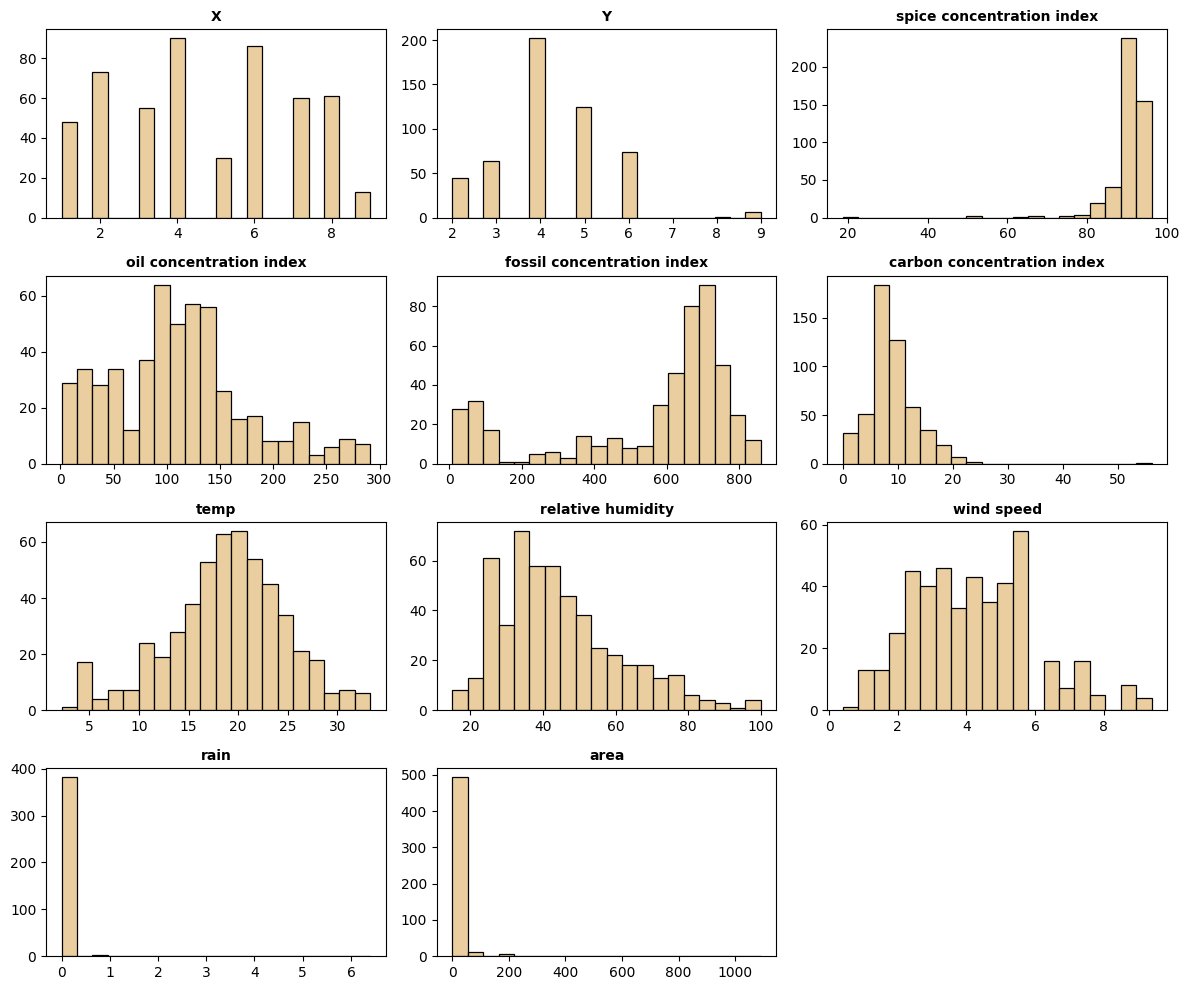

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
axes = axes.flatten()

sand_color = '#E6C287' 

for i, col in enumerate(num_cols):
    sns.histplot(
        data=data, 
        x=col, 
        ax=axes[i], 
        color=sand_color, 
        edgecolor='black',
        alpha=0.8,
        bins=20
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

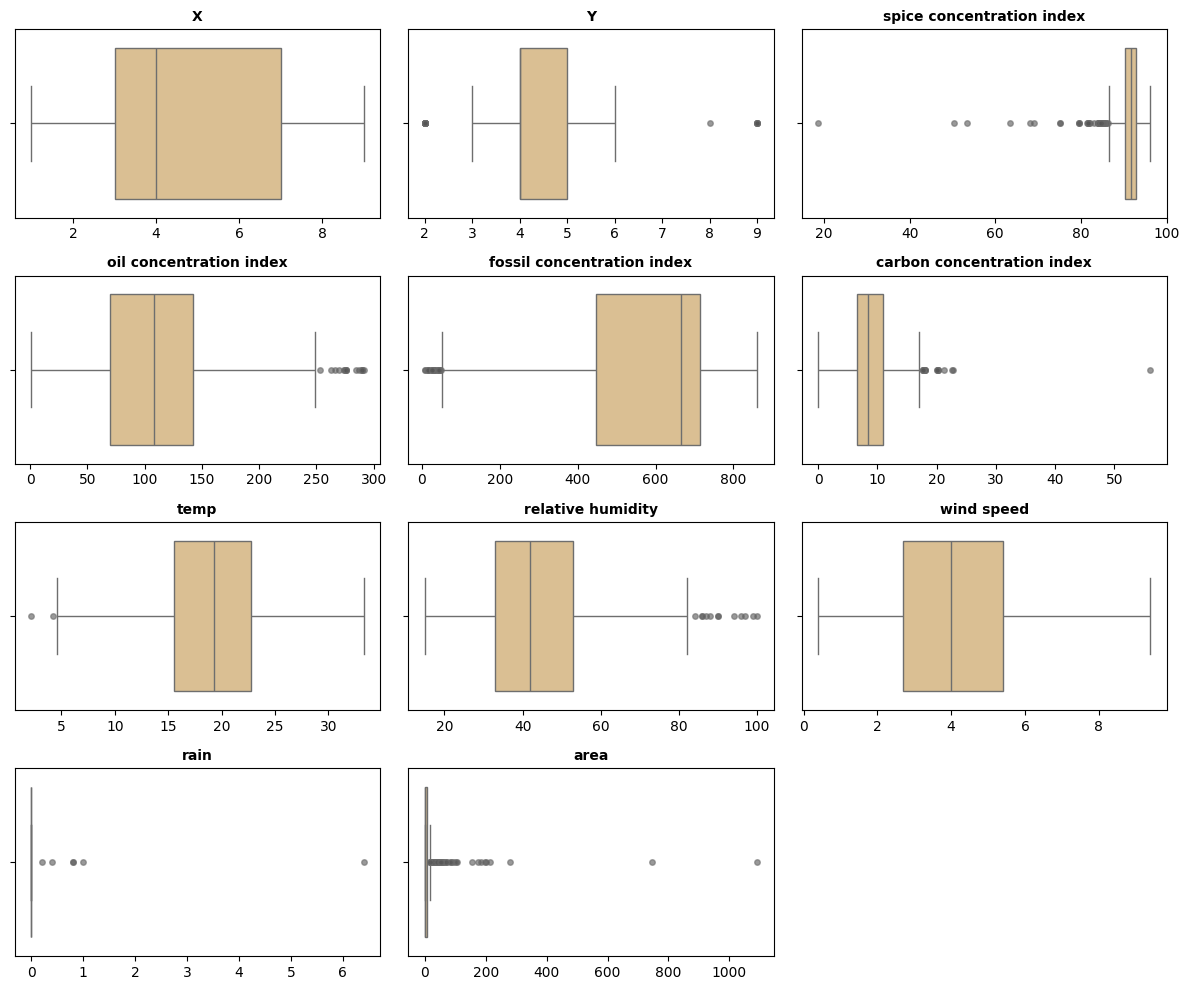

In [16]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
axes = axes.flatten()

sand_color = '#E6C287' 

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=data, 
        x=col, 
        ax=axes[i], 
        color=sand_color,
        flierprops={'marker': 'o', 'markerfacecolor': '#555555', 'markersize': 4, 'alpha': 0.6}
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Оставим центральные 98% значений всех числовых признаков, кроме `X`, `wind_speed`, `rain` (от 2-го до 98-го перцентиля), так как они имеют выбросы.

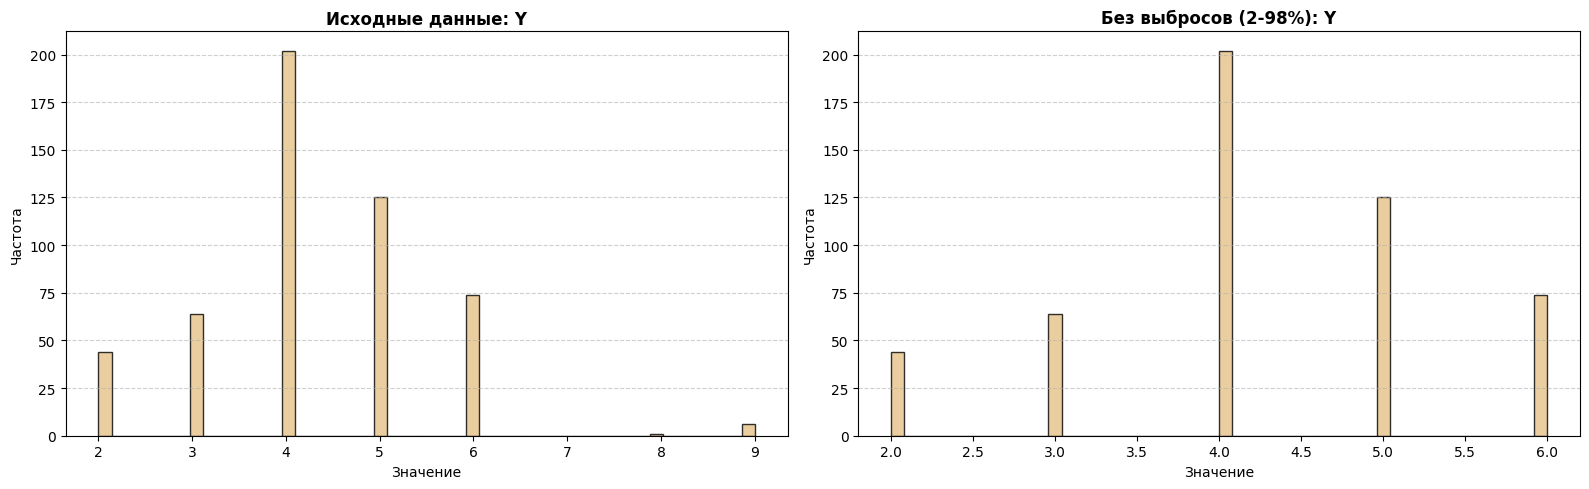

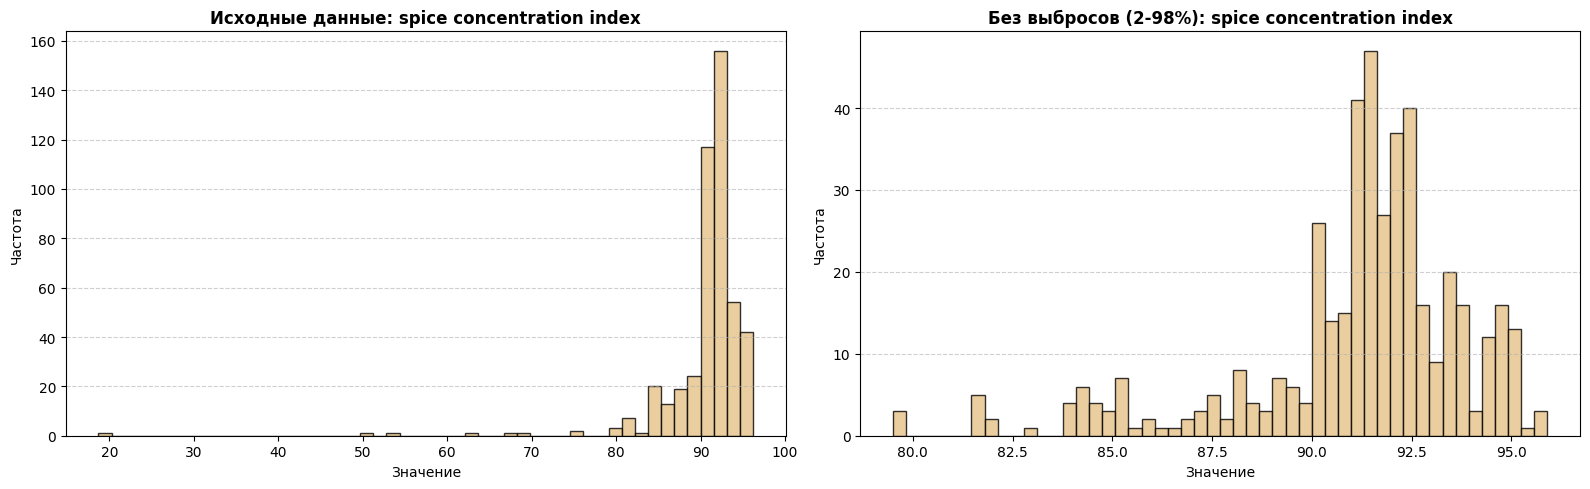

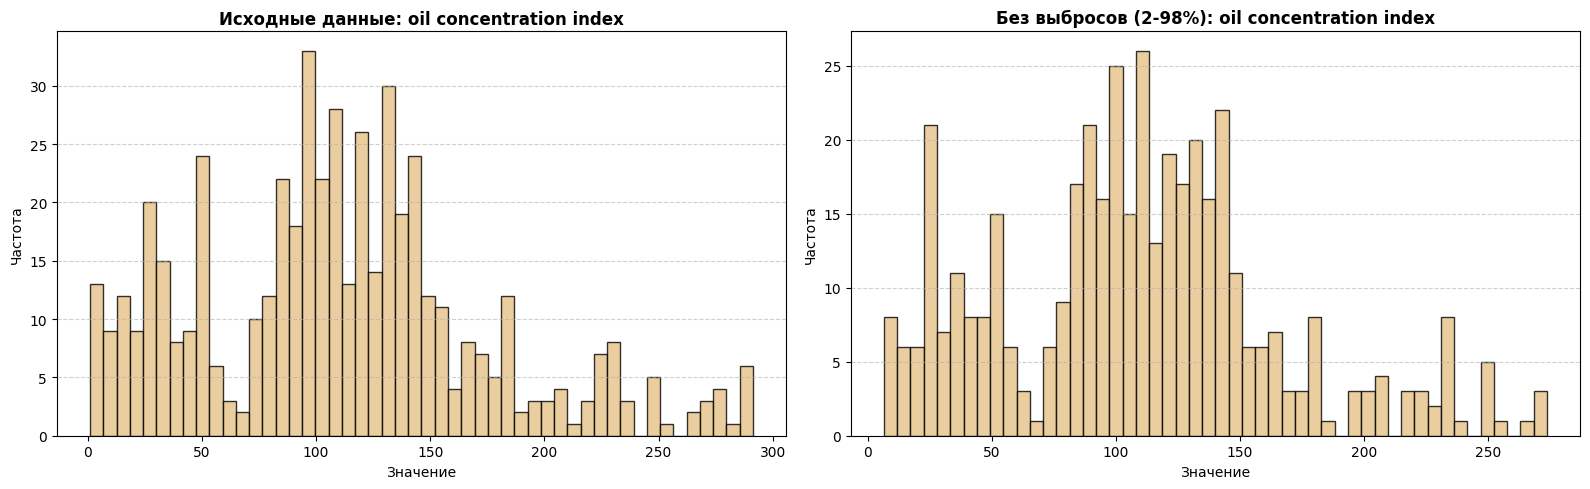

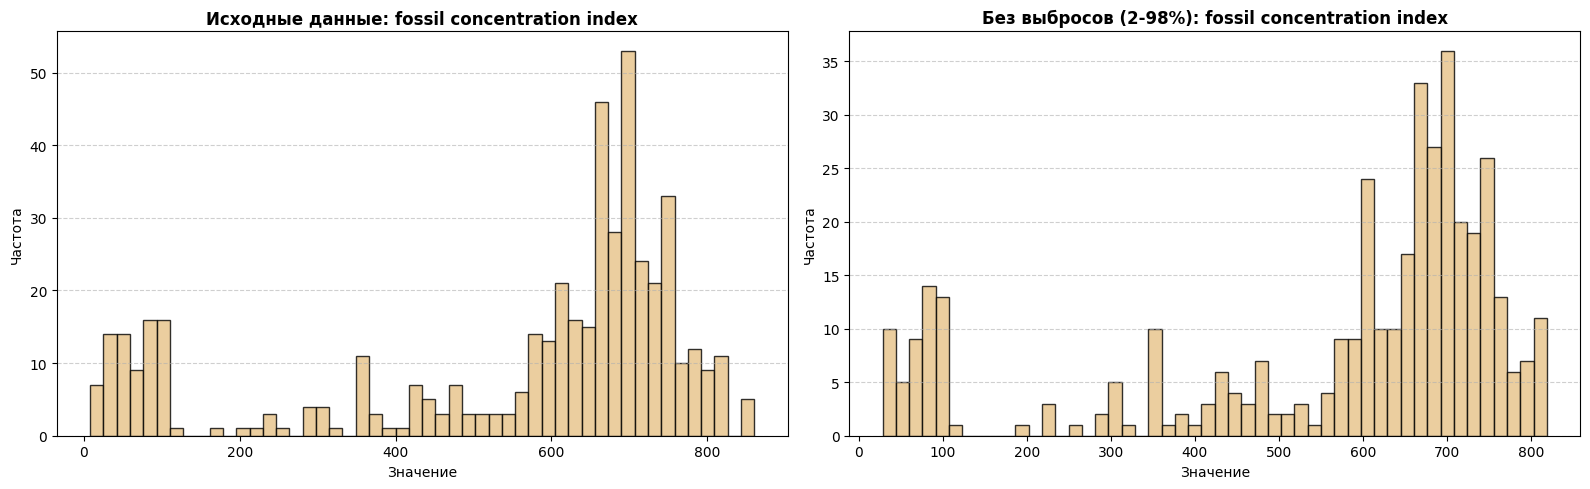

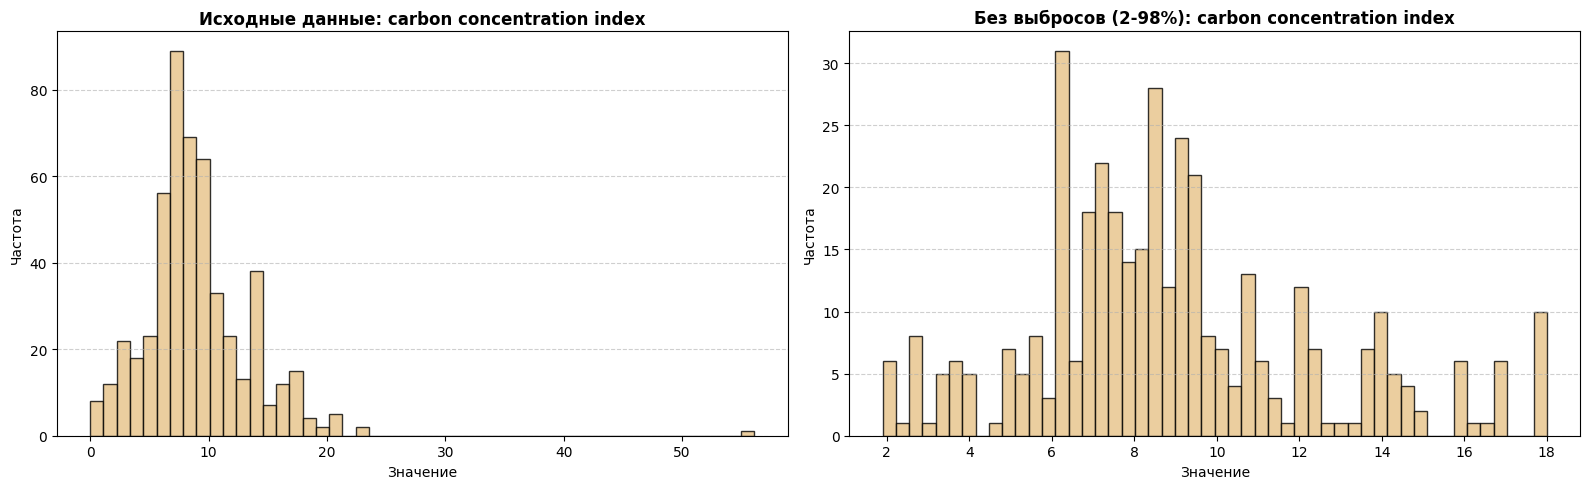

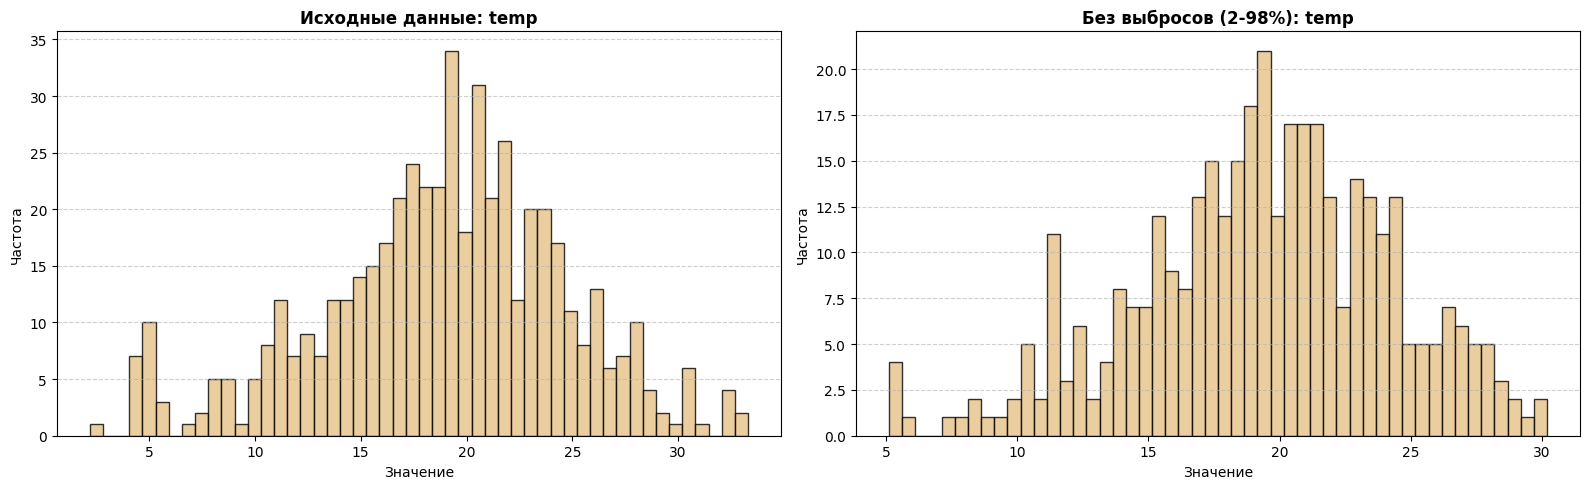

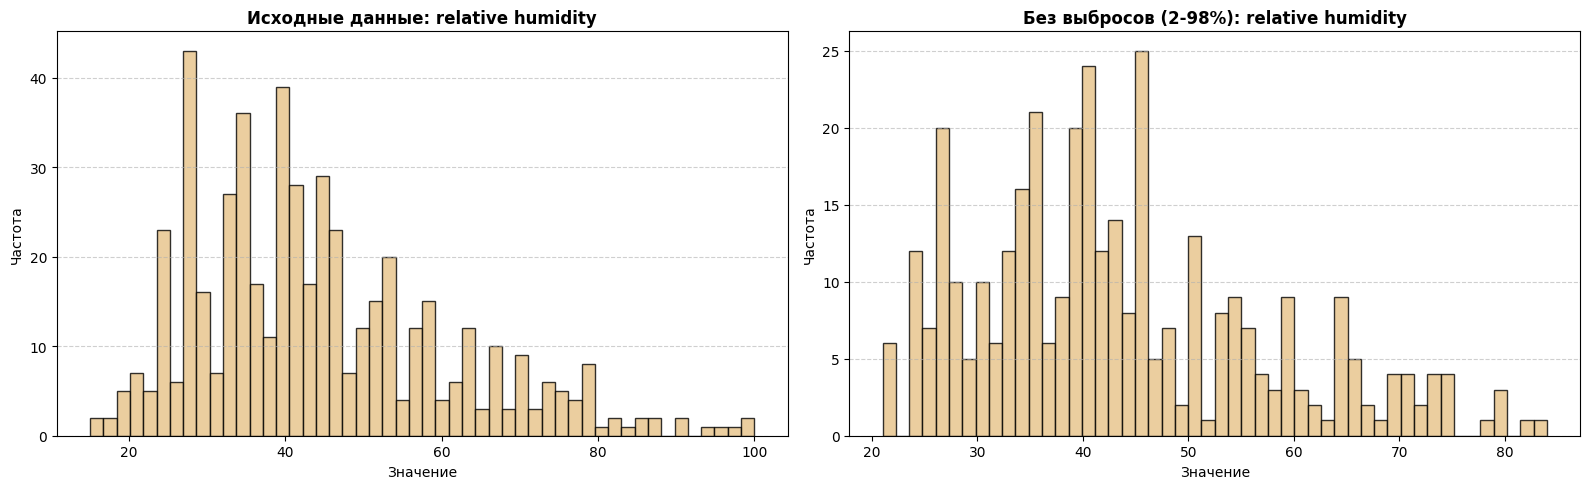

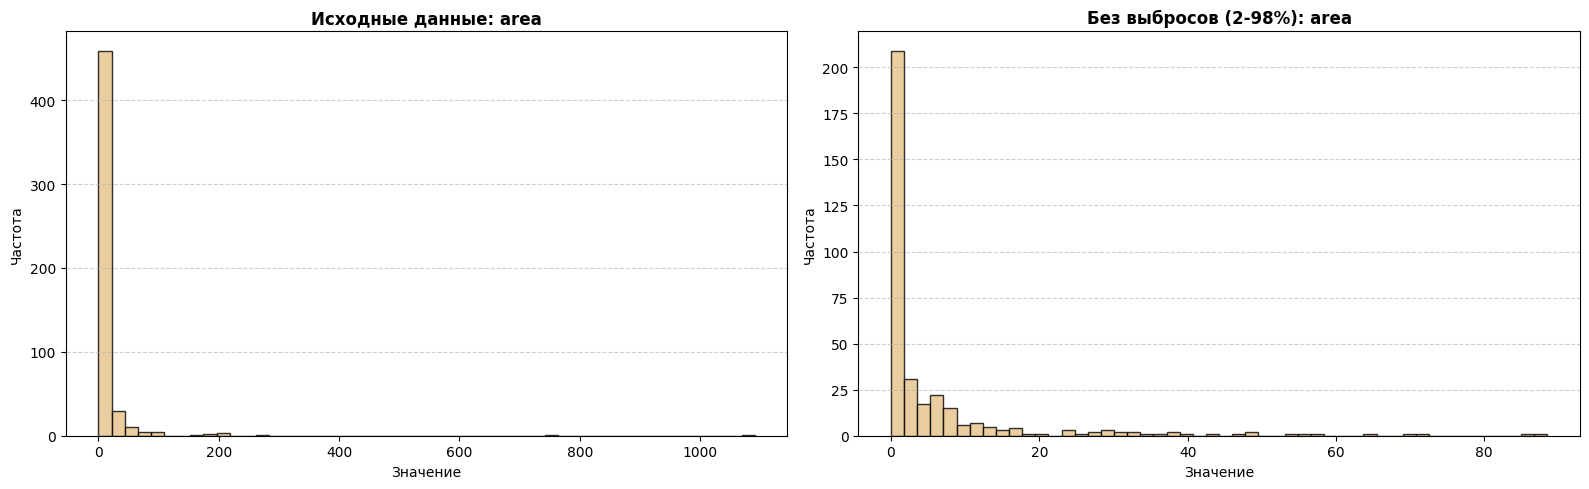

In [17]:
data_filtered = data.copy()

num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

exclude_cols = ['X', 'wind speed', 'rain']
col_for_per = [col for col in num_cols if col not in exclude_cols]

sand_color = '#E6C287'

for col in col_for_per:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].hist(
        data[col],
        bins=50, 
        color=sand_color,
        edgecolor='black',
        alpha=0.8
    )
    axes[0].set_title(f'Исходные данные: {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Частота')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    lower_bound = data[col].quantile(0.02)
    upper_bound = data[col].quantile(0.98)

    data_filtered = data_filtered[(data_filtered[col] >= lower_bound) & (data_filtered[col] <= upper_bound)]

    axes[1].hist(
        data_filtered[col],
        bins=50,
        color=sand_color,
        edgecolor='black',
        alpha=0.8
    )
    axes[1].set_title(f'Без выбросов (2-98%): {col}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Значение')
    axes[1].set_ylabel('Частота')
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

## <a id='toc1_7_'></a>[1.7. Подведение итогов раздела 1](#toc0_)
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

В данном разделе была произведена первоначальная загрузка данных, анализ типов и заполнение пропущенных значений. Была проведена формализация задачи регрессии и разведочный анализ (EDA). В результате датасет подготовлен к следующему этапу - генерации новых признаков.

# <a id='toc2_'></a>[2. Генерация новых признаков](#toc0_)

## <a id='toc2_1_'></a>[2.1. Корреляционный анализ входных признаков (построение тепловых карт корреляции)](#toc0_)

## <a id='toc2_2_'></a>[2.2. Исправление проблемы мультиколлинеарности в данных](#toc0_)

## <a id='toc2_3_'></a>[2.3. Скалирование данных](#toc0_)

## <a id='toc2_4_'></a>[2.4. Подведение итогов раздела 2](#toc0_)
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

# <a id='toc3_'></a>[3. Выбор моделей ML и метрик](#toc0_)

`ячейки для выбора моделей ML`
<!-- Третий раздел самый богатый на писанину. Вам необходимо сначала обосновать выбор моделей, а затем все отобранные модели описать (расписать концептуально, как они работают) -->

`ячейки для выбора метрик`
<!-- И снова писанина: необходимо не только описать, какие метрики вы используете, но привести формулы их вычисления -->

In [18]:
# ячейка для импорта моделей из пула

In [19]:
# ячейки для формирования сеток гиперпараметров

In [20]:
# ячейка для импорта метрик из пула

# <a id='toc4_'></a>[4. Обучение моделей ML и подбор гиперпараметров](#toc0_)

In [21]:
# ячейки для подбора гиперпараметров и обучения лучших моделей

# <a id='toc5_'></a>[5. Вычисление метрик на новых данных](#toc0_)

In [22]:
# ячейки для вычисления метрик на лучших моделях и их сопоставление

# <a id='toc6_'></a>[6. Результат работы](#toc0_)

`ячейка для подведения итогов по всей работе`
<!-- Тут обычно пишется, какая модель показала себя лучше, с какими метриками и рекомендуется ли ее выводить в прод -->